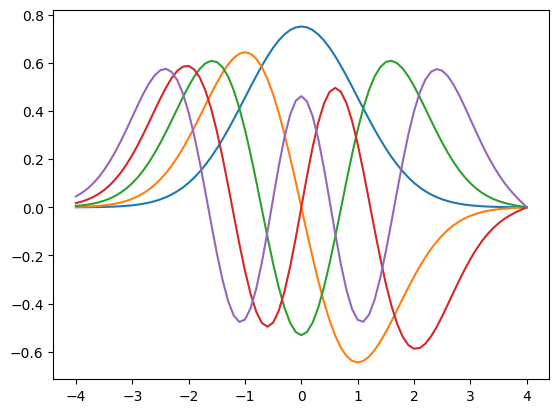

In [1]:
# AMATH 581 HW 2
# Jonathan McCormack 
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy import linalg

#-----------------------
# Exercise 1: Solve the BVP using the Shooting method
#-----------------------

tol = 1e-4 # define a tolerance level
L = 4 # define numerical limit of integration
x_span = [-L, L]
x_eval = np.linspace(-L, L, 81)

def rhseval(x, y, e):
    y1, y2 = y
    dy1 = y2
    dy2 = (x**2-e)*y1
    return dy1, dy2

e_start = 0
plt.figure()
A6 = np.zeros((5,1))

for modes in range(1, 6):
    e = e_start
    de = 1
    
    for j in range(1000):
        A = np.sqrt(16 - e)
        y0 = [1, A]
        
        sol = solve_ivp(rhseval, x_span, y0, t_eval=x_eval, args = [e])
        y = sol.y.T
        
        if abs(y[-1,0]) < tol:
            A6[modes-1] = e
            break
        elif (-1)**(modes)*y[-1,0] < 0:
            e = e + de
        else:
            e = e - de/2
            de = de/2

    e_start = e + 0.1
    norm = np.trapezoid(y[:,0] * y[:,0], x_eval)
    ysol = y[:,0]/np.sqrt(norm)
    if modes == 1:
        A1 = np.abs(ysol.reshape(-1,1))
    elif modes == 2:
        A2 = np.abs(ysol.reshape(-1,1))
    elif modes == 3:
        A3 = np.abs(ysol.reshape(-1,1))
    elif modes == 4:
        A4 = np.abs(ysol.reshape(-1,1))
    else:
        A5 = np.abs(ysol.reshape(-1,1))
    plt.plot(x_eval, ysol)

plt.show()

del e_start, e, de, modes, j, A, y0, sol, y, norm, ysol

In [2]:
#-----------------------
# Exercise 2: Solve the BVP using the Direct Method
#-----------------------

tol = 1e-4 # define a tolerance level
L = 4 # define numerical limit of integration
x_span = [-L, L]
x_eval = np.linspace(-L, L, 81)
dx = 0.1

A = np.zeros((79,79))

for i in range(1,78):
    A[i, i-1] = -1/.01
    A[i, i] = (2+(.01*x_eval[i+1]**2))/.01
    A[i, i+1] = -1/.01

A[0, 0] = (2/3 + (.01*x_eval[1]**2))/.01
A[-1, -1] = (2/3 + (.01*x_eval[-2]**2))/.01
A[0, 1] = (-2/3)/.01
A[-1, -2] = (-2/3)/.01

eval, evec = np.linalg.eig(A)
index = eval.argsort()
evalsort = eval[index]
evecsort = evec[:,index]

vstart = np.zeros(5)
vend = np.zeros(5)
A12 = np.zeros((5,1))
for i in range(5):
    A12[i] = evalsort[i]
    vstart[i] = (4*evecsort[0,i]-evecsort[1,i])/(2*dx*np.sqrt(L**2-evalsort[i])+3)
    vend[i] = (evecsort[-2,i]-4*evecsort[-1,i])/(-2*dx*np.sqrt(L**2-evalsort[i])-3)
    
    vtemp = np.append(vstart[i], evecsort[:,i])   
    vfinal = np.append(vtemp, vend[i])
    norm = np.trapezoid(vfinal*vfinal, x_eval)
    vsol = vfinal/np.sqrt(norm)
    if i == 0:
        A7 = np.abs(vsol.reshape(-1,1))
    elif i == 1:
        A8 = np.abs(vsol.reshape(-1,1))
    elif i == 2:
        A9 = np.abs(vsol.reshape(-1,1))
    elif i == 3:
        A10 = np.abs(vsol.reshape(-1,1))
    else:
        A11 = np.abs(vsol.reshape(-1,1))
